In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xlrd.compdoc import x_dump_line

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.boston_housing.load_data(path="boston_housing.npz", test_split=0.2, seed=113)

In [3]:
print(x_train.shape)
print(len(x_train))
x_train

(404, 13)
404


array([[1.23247e+00, 0.00000e+00, 8.14000e+00, ..., 2.10000e+01,
        3.96900e+02, 1.87200e+01],
       [2.17700e-02, 8.25000e+01, 2.03000e+00, ..., 1.47000e+01,
        3.95380e+02, 3.11000e+00],
       [4.89822e+00, 0.00000e+00, 1.81000e+01, ..., 2.02000e+01,
        3.75520e+02, 3.26000e+00],
       ...,
       [3.46600e-02, 3.50000e+01, 6.06000e+00, ..., 1.69000e+01,
        3.62250e+02, 7.83000e+00],
       [2.14918e+00, 0.00000e+00, 1.95800e+01, ..., 1.47000e+01,
        2.61950e+02, 1.57900e+01],
       [1.43900e-02, 6.00000e+01, 2.93000e+00, ..., 1.56000e+01,
        3.76700e+02, 4.38000e+00]])

In [4]:
y_train

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

In [5]:
model = keras.Sequential()
# model.add(BatchNormalization()) Das geht nicht!!!
model.add(keras.layers.Dense(32, activation="relu", input_shape=(x_train.shape[1],)))
model.add(keras.layers.Dense(16, activation="relu"))
model.add(keras.layers.Dense(1))

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                448       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 993
Trainable params: 993
Non-trainable params: 0
_________________________________________________________________


In [6]:
model.fit(x_train, y_train, epochs=32, batch_size=8, verbose=0)

In [7]:
model.evaluate(x_test, y_test)

4/4 [==============================] - 0s 0s/step - loss: 36.8810 - mae: 4.1926


[36.88096237182617, 4.192588806152344]

<AxesSubplot:>

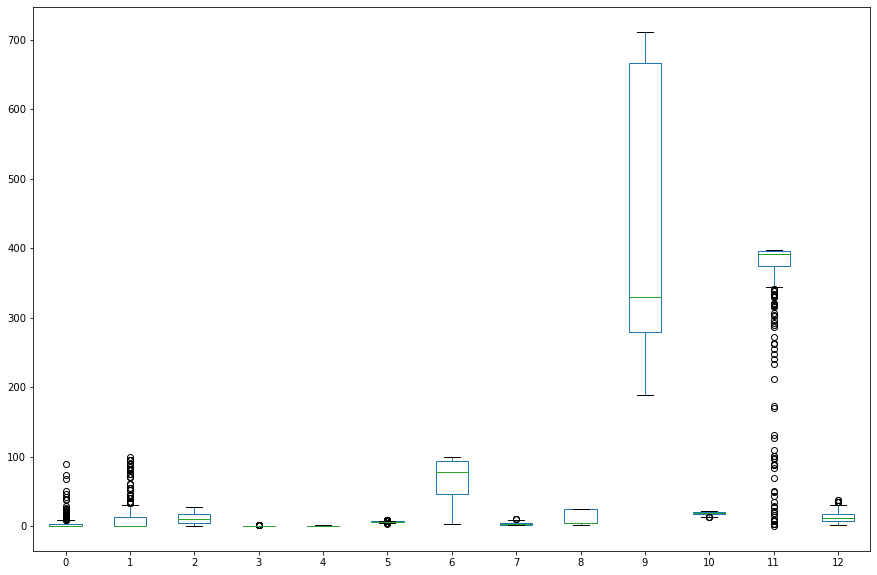

In [8]:
df_xtrain = pd.DataFrame(x_train)
df_xtrain.plot(kind="box", figsize=(15,10))

<AxesSubplot:>

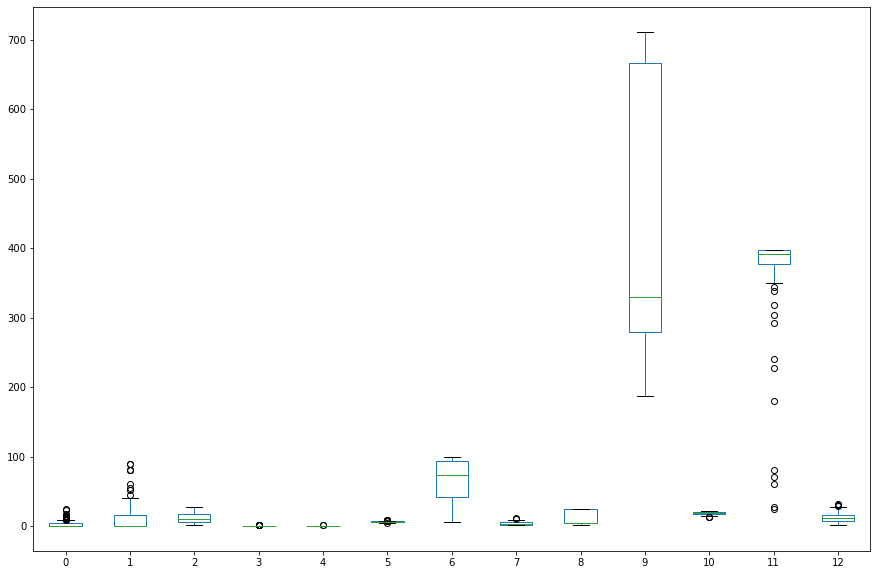

In [9]:
df_xtest = pd.DataFrame(x_test)
df_xtest.plot(kind="box", figsize=(15,10))

In [10]:
# Normalisierung
df_xtrain_new = (df_xtrain-df_xtrain.mean())/df_xtrain.std()
df_xtrain_new

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.271909,-0.483017,-0.435222,-0.256515,-0.165022,-0.176224,0.812055,0.116554,-0.625474,-0.594433,1.147078,0.447522,0.824198
1,-0.402927,2.988079,-1.332260,-0.256515,-1.213677,1.892000,-1.907995,1.246040,-0.855402,-0.348001,-1.716061,0.431371,-1.327556
2,0.124785,-0.483017,1.027052,-0.256515,0.627864,-1.827422,1.109113,-1.185969,1.673810,1.563349,0.783505,0.220344,-1.306880
3,-0.400996,-0.483017,-0.868325,-0.256515,-0.361112,-0.324156,-1.235140,1.105809,-0.510509,-1.093307,0.783505,0.447522,-0.652118
4,-0.005627,-0.483017,1.027052,-0.256515,1.326967,0.153452,0.693948,-0.577856,1.673810,1.563349,0.783505,0.389399,0.263171
...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,-0.381500,-0.483017,-0.615804,-0.256515,-0.932331,-0.937015,-0.250912,1.156247,-0.740438,-1.039213,-0.261768,0.447522,0.476830
400,-0.387740,0.358461,-0.608463,-0.256515,-0.795920,-0.038155,-1.886521,0.339240,-0.740438,-1.099318,0.056358,0.447522,-0.847857
401,-0.401532,0.989570,-0.740597,-0.256515,-1.018440,-0.332609,-1.635990,1.428632,-0.970366,-0.612465,-0.716235,0.079341,-0.676930
402,-0.172706,-0.483017,1.244338,-0.256515,2.674020,-0.786266,1.055428,-1.042782,-0.510509,-0.017422,-1.716061,-0.986421,0.420314


In [11]:
df_xtest_new = (df_xtest-df_xtest.mean())/df_xtest.std()
df_xtest_new

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2.790251,-0.505354,0.964844,-0.328070,1.225693,0.118755,1.141760,-0.914835,1.598200,1.400864,0.900683,-4.257271,2.500898
1,-0.552577,-0.505354,-0.177142,-0.328070,0.025852,-0.656156,0.897227,-0.696891,-0.453755,0.081741,-0.283459,0.389023,0.583163
2,-0.565292,-0.505354,-0.857535,-0.328070,-0.265018,-0.549067,-0.738730,0.336230,-0.567752,-1.090814,0.900683,0.413664,-0.383172
3,-0.338516,-0.505354,1.173761,3.018245,0.553055,-0.154918,0.886895,-0.930087,-0.567752,-0.081741,-1.812974,-0.318977,-1.016443
4,-0.562214,-0.505354,-0.956347,-0.328070,-0.864939,-0.346787,-0.346100,-0.111086,-0.795747,-0.961156,0.061916,0.391551,-0.577335
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,0.071085,-0.505354,0.964844,3.018245,1.580191,3.608085,0.552815,-0.885423,1.598200,1.400864,0.900683,-0.121475,-1.047807
98,-0.560828,-0.505354,0.220930,-0.328070,-0.974015,-0.120709,-2.095713,0.100639,-0.567752,-0.109927,0.160594,0.388644,-0.825267
99,-0.234235,-0.505354,1.173761,3.018245,0.553055,2.153454,1.079765,-0.828279,-0.567752,-0.081741,-1.812974,0.321547,-1.551138
100,-0.508878,-0.505354,-0.714963,3.018245,-0.337736,0.887716,0.745686,-0.483317,-0.225760,-0.622920,-0.480816,0.347956,-0.387653


<AxesSubplot:>

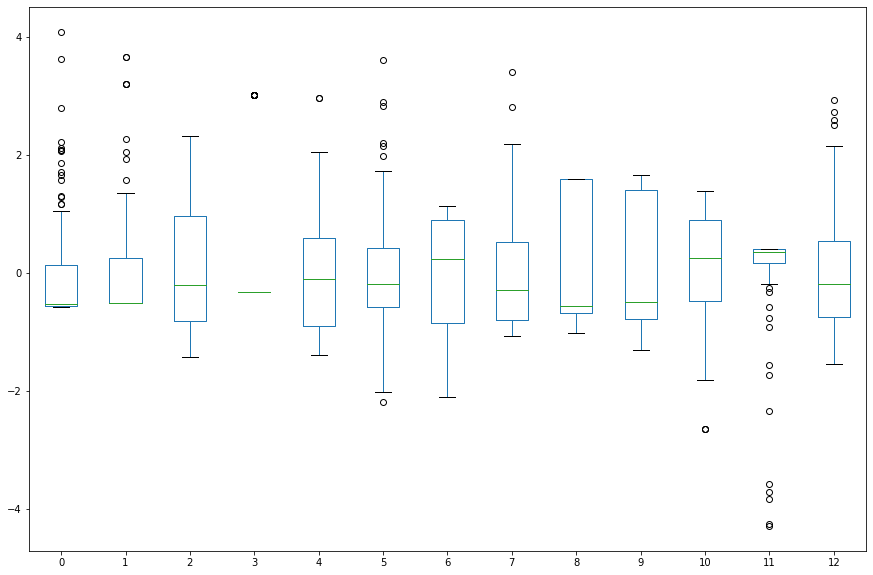

In [12]:
df_xtest_new.plot(kind="box", figsize=(15,10))

In [13]:
# 19.1.3
x_train = df_xtrain_new.to_numpy()
x_test = df_xtest_new.to_numpy()

In [14]:
model.fit(x_train, y_train, epochs=32, batch_size=8, verbose=0)

In [15]:
model.evaluate(x_test, y_test)

4/4 [==============================] - 0s 4ms/step - loss: 18.9152 - mae: 2.9288


[18.91518211364746, 2.9288129806518555]